---

<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>Aula 01 - Conceitos Elementares</strong></h2>
<h3 style="text-align: center;"><strong>Prof. Jones Egydio</strong></h3>
<h4 style="text-align: center;"><strong>FIAP - 2026</strong></h4>
<br>
<br>



---

# **Aula 1: Data Science e IA + Ferramentas na prática**

## **Objetivos**
- Entender os conceitos básicos de Data Science e IA;
- Praticar algumas ferramentas: **Jupyter, python, numpy, pandas, matplotlib**

---
## **1. Data Science e Inteligência Artificial**

### **1.1 O papel do cientista de dados**

**Definição:** profissional que transforma dados em decisões. 

Normalmente atua em: 

- (1) entender o problema;
- (2) coletar/limpar dados;
- (3) explorar padrões;
- (4) criar análises/modelos;
- (5) comunicar resultados e medir impacto.


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True)
df = iris.frame  # já vem com as features + target
df.head()

* **Fonte:** https://archive.ics.uci.edu/dataset/53/iris

### **1.2 A relação entre Data Science e Inteligência Artificial**

**Definição:** Data Science é o conjunto de análises orientadas por dados (estatística + programação + negócio). 

IA é um conjunto que cria sistemas capazes de “executar tarefas inteligentes”, muitas vezes com modelos de machine learning.

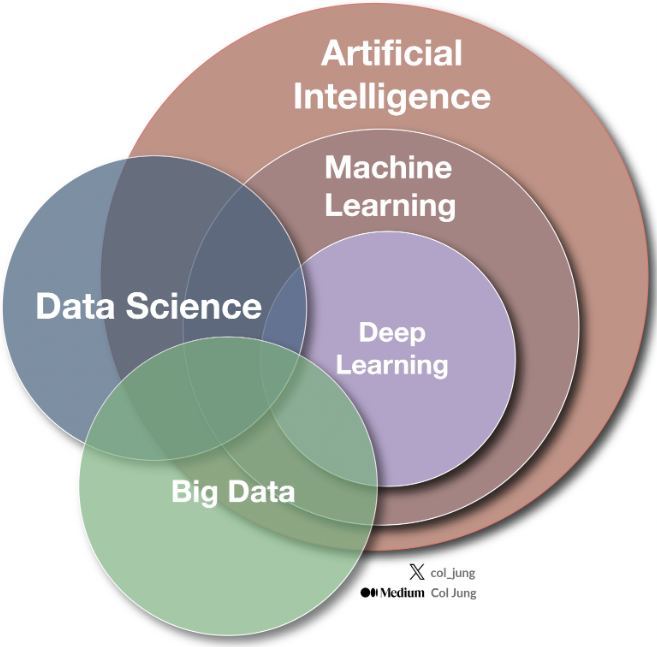

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# 1) carregar o dataset iris em um DataFrame (df)
iris = load_iris(as_frame=True)
df = iris.frame  # features + coluna "target"

# 2) separar X e y
X = df.drop(columns=["target"])
y = df["target"]

# 3) split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4) treinar o modelo
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# 5) predição e métrica
pred = clf.predict(X_test)
acc = accuracy_score(y_test, pred)
print("accuracy:", acc)

# 6) gráfico: matriz de confusão
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("matriz de confusão - logistic regression (iris)")
plt.show()

### **1.3 Carreiras em Data Science e IA**
**Áreas comuns:**

- Analista de dados (dashboards, métricas)
- Cientista de dados (experimentos, modelagem)
- Engenheiro de dados (pipelines, dados em produção)
- ML Engineer (treino + deploy)
- Analytics Engineer (modelagem de dados + camadas analíticas)
- Product/AI Analyst (decisões de produto)

### **1.4 Por que programadores têm que aprender data science?**

Os produtos modernos são guiados por dados (telemetria, recomendação, busca, detecção de fraude, personalização). Entender dados ajuda a projetar sistemas melhores, medir impacto e evitar conclusões erradas.

**Na prática:** um programador precisa ler dados, filtrar, agregar e visualizar rapidamente.

In [ ]:
import numpy as np

# correlação com o target (apenas para ter uma sensibilidade inicial; target aqui é numérico por classe)
corr = df.corr(numeric_only=True)["target"].sort_values(ascending=False)
corr

In [ ]:
# exemplo de agregação e checagem rápida: média por classe (target)
df.groupby("target").mean(numeric_only=True)

### **1.5 Vantagens para quem está migrando de carreira**


Quem migra normalmente ganha vantagem ao combinar conhecimento anterior (negócio/engenharia/saúde etc.) com análise de dados. Isso melhora definição de problema, interpretação e comunicação.

**Na prática:** comunicar um insight em uma frase + gráfico.

In [ ]:
import matplotlib.pyplot as plt

means = df.groupby("target").mean(numeric_only=True)["petal length (cm)"]
means.plot(kind="bar")
plt.title("média de petal length por classe")
plt.ylabel("cm")
plt.show()

---
## **2. Ferramentas Essenciais**

### **2.1 Primeiros passos no Google Colab e Jupyter**

**Colab** é um ambiente de notebook no navegador. Você consegue executar python na nuvem, instalar libs com `pip`, usar gpu (quando disponível) e salvar arquivos no drive.

**Jupyter** é um ambiente similar ao **Colab**. Em geral, está presente em aplicações profissionais e acadêmicas.

In [ ]:
import sys, platform
print("python:", sys.version.split()[0])
print("plataforma:", platform.platform())

### **2.2 por que python é a linguagem preferida em data science**

Python tem sintaxe simples, ecossistema enorme (numpy/pandas/sklearn/matplotlib), comunidade forte e integração com produção.

In [ ]:
import numpy as np
import time

arr = np.random.rand(2_000_000)

# loop manual
t0 = time.time()
s = 0.0
for v in arr:
    s += v
t1 = time.time()

# vetorizado
t2 = time.time()
s2 = arr.sum()
t3 = time.time()

print("loop:", round(t1-t0, 4), "s | soma:", round(s, 3))
print("numpy:", round(t3-t2, 4), "s | soma:", round(float(s2), 3))

### **2.3 pandas e matplotlib: o kit essencial**

**Definição:**
- **pandas**: estrutura `DataFrame` para dados tabulares (colunas/linhas)
- **matplotlib**: base para gráficos em python
- **numpy**: base numérica (arrays)

A seguir, vamos conectar cada conceito com um exemplo.

#### **2.3.1 Pandas vs polars: qual usar?**

**definição:**
- **pandas** é o padrão do mercado e muito integrado com o ecossistema.
- **polars** costuma ser mais rápido em operações grandes e usa execução mais eficiente.


In [ ]:
# tarefa: filtrar, criar coluna, agregar

import pandas as pd

df2 = df.copy()
df2["petal_area"] = df2["petal length (cm)"] * df2["petal width (cm)"]

res_pandas = (
    df2[df2["sepal length (cm)"] > 5.5]
    .groupby("target")["petal_area"]
    .mean()
    .sort_values(ascending=False)
)

res_pandas

#### **2.3.2 Falando de pandas**
**Pandas** trabalha com:
- leitura/escrita (csv, parquet, excel)
- inspeção (`head`, `info`)
- limpeza (nulos, tipos)
- transformação (filtros, joins, groupby)
- estatística descritiva (`describe`)

**exemplo:** inspeção e estatística descritiva.

In [ ]:
df.head(3)

In [ ]:
df.info()

In [ ]:
df.describe(include="all")  # aqui entra o describe do pandas

#### **2.3.3 Carregando um novo dataset**

**Definição:** carregar dados significa trazê-los para um `DataFrame` (ou array). No dia a dia, você usa muito `pd.read_csv`.

**Exemplo:** vamos salvar um csv local e ler de volta para simular o fluxo real.

In [ ]:
from pathlib import Path

tmp = Path("iris_exemplo.csv")
df.to_csv(tmp, index=False)

df_csv = pd.read_csv(tmp)
df_csv.head()

#### **2.3.4 Navegando pelo pandas**

**Definição:** “navegar” é selecionar, filtrar, ordenar, criar colunas, agrupar e tratar valores faltantes.

**Exemplos essenciais:**
- seleção de colunas
- `loc/iloc`
- filtro booleano
- criação de coluna
- ordenação
- `value_counts`
- `groupby`

In [ ]:
# seleção de colunas
df[["sepal length (cm)", "sepal width (cm)"]].head()

In [ ]:
# loc (por rótulo) e iloc (por posição)
print("loc 0..2, 2 colunas:")
display(df.loc[0:2, ["petal length (cm)", "petal width (cm)"]])

print("iloc 0..2, colunas 0..1:")
display(df.iloc[0:3, 0:2])

In [ ]:
# filtro booleano
df[df["petal length (cm)"] > 4.5].head()

In [ ]:
# criar coluna
df_nav = df.copy()
df_nav["petal_area"] = df_nav["petal length (cm)"] * df_nav["petal width (cm)"]
df_nav[["petal length (cm)", "petal width (cm)", "petal_area"]].head()

In [ ]:
# ordenar
df_nav.sort_values("petal_area", ascending=False).head(5)

In [ ]:
# value_counts (contagem por classe)
df["target"].value_counts()

In [ ]:
# groupby (médias por classe)
df_nav.groupby("target")[["sepal length (cm)", "petal_area"]].mean()

### **2.4 Conhecendo o `matplotlib`**

**Definição:** matplotlib é a base dos gráficos em python. Você controla figura, eixos, títulos, rótulos e estilos.

#### **2.4.1 Gráfico de linhas**

**Quando usar:** evolução no tempo ou comparação de tendência.

**Exemplo:** criar uma série sintética (só para o formato de linha).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 50)
y = np.cumsum(np.random.randn(50))  # passeio aleatório

plt.plot(x, y)
plt.title("Gráfico de linhas (exemplo sintético)")
plt.xlabel("passo")
plt.ylabel("Valor acumulado")
plt.show()

#### **2.4.2 Gráfico de barras**

**Quando usar:** comparar quantidades entre categorias.

**Exemplo:** quantos exemplos há por classe no iris.

In [ ]:
counts = df["target"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("quantidade de exemplos por classe")
plt.xlabel("classe (target)")
plt.ylabel("contagem")
plt.show()

#### **2.4.3 Gráfico de dispersão**

**Quando usar:** relação entre duas variáveis numéricas.

**Exemplo:** sepal length vs petal length, colorindo por classe.

In [ ]:
for cls in sorted(df["target"].unique()):
    subset = df[df["target"] == cls]
    plt.scatter(subset["sepal length (cm)"], subset["petal length (cm)"], label=f"classe {cls}")

plt.title("dispersão: sepal length vs petal length")
plt.xlabel("sepal length (cm)")
plt.ylabel("petal length (cm)")
plt.legend()
plt.show()

### **2.5 Conceituação estatística**


#### **2.5.1 Amostras**

**Definição:** amostra é um subconjunto de dados usado para estimar características da população. amostrar é útil quando a população é grande/cara de medir.

**Na prática:** comparar estatísticas da amostra com a base toda.

In [ ]:
sample = df.sample(n=30, random_state=7)
print("média petal length (população):", df["petal length (cm)"].mean())
print("média petal length (amostra):  ", sample["petal length (cm)"].mean())

#### **2.5.2 Classificação estatística**

**Definição:** classificar dados é identificar tipos (numérico/categórico/ordinal) e, em ML, prever rótulos (classes).

**Na prática (tipos):** ver dtypes e transformar o target em categoria.

#### 1) Dado numérico (quantitativo)

**Definição:** valores que representam **quantidades** e permitem operações matemáticas (somar, calcular média, desvio padrão, etc.).
**subtipos comuns:**

* **Discreto:** contagens (número de compras, número de filhos).
* **Contínuo:** medidas (altura, peso, preço, tempo).

**exemplo (pandas):**

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "idade": [18, 22, 35, 41],          # discreto (contagem de anos)
    "salario": [2500.0, 3200.5, 5400.0, 6100.0]  # contínuo (medida)
})

df.dtypes

In [ ]:
# Operações típicas:

df[["idade", "salario"]].describe()

#### 2) Dado categórico (qualitativo nominal)

**Definição:** valores que representam **categorias sem ordem natural**. você pode contar frequências, comparar igualdade, agrupar, mas **não faz sentido** calcular “média” da categoria.

**Exemplos:** cor, cidade, marca, tipo de pagamento.

**exemplo (pandas):**

In [ ]:
df = pd.DataFrame({
    "cor": ["azul", "preto", "azul", "vermelho"],
    "cidade": ["sp", "rj", "sp", "bh"]
})

df.dtypes

In [ ]:
# Converter para categoria (melhora memória e deixa explícito):

df["cor"] = df["cor"].astype("category")
df["cidade"] = df["cidade"].astype("category")
df.dtypes

In [ ]:
# Análises típicas:

df["cor"].value_counts()

#### 3) Dado ordinal (qualitativo ordinal)

**Definição:** valores categóricos com **ordem natural**, mas sem garantir que a “distância” entre níveis seja igual.
Ex.: “ruim < ok < bom < excelente”.
Você consegue comparar ordem, mas dizer que “excelente é 2x melhor que bom” não faz sentido.

**Exemplo (pandas):**

In [ ]:
df = pd.DataFrame({
    "satisfacao": ["ruim", "ok", "bom", "excelente", "bom"]
})

ordem = ["ruim", "ok", "bom", "excelente"]
df["satisfacao"] = pd.Categorical(df["satisfacao"], categories=ordem, ordered=True)

df.dtypes

In [ ]:
# Comparações e ordenação funcionando:

df.sort_values("satisfacao")

In [ ]:
# Transformar em número (às vezes útil em ML, com cuidado):

df["satisfacao_code"] = df["satisfacao"].cat.codes
df

#### 2.5.3 Forma dos dados

**Definição:** forma = número de linhas (observações) e colunas (variáveis). Também se fala em “wide” (muitas colunas) vs “long” (mais linhas, dados empilhados).

**Na prática:** checar shape e transformar de wide para long com `melt`.

In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame  # features + coluna "target"

In [ ]:
df.head(3)

In [ ]:
print("shape:", df.shape)
df_long = df.melt(id_vars=["target"], var_name="feature", value_name="value")
df_long.head()

### **2.6 Exercícios propostos (novo dataset)**

Agora é com você. Vamos usar **outro dataset** para praticar.

Dataset: **Wine** (sklearn) — dados de vinhos com várias features numéricas e classes.

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df_wine = wine.frame
df_wine.head()

#### Tarefa 1 — inspeção e `describe`
1) Use `head`, `info` e `describe`.
2) Responda: quais colunas parecem ter escalas muito diferentes?

#### Tarefa 2 — navegação e filtros
1) Crie um filtro para ver apenas linhas onde `alcohol` é maior que a mediana.
2) Ordene pela coluna `color_intensity` (desc).
3) Mostre as 5 primeiras linhas.

#### Tarefa 3 — criação de feature
1) Crie uma nova coluna `phenols_ratio = total_phenols / flavanoids`.
2) Lide com divisões por zero (se aparecer).
3) Mostre `describe` dessa nova coluna.

#### Tarefa 4 — gráficos
1) Faça um gráfico de barras com a contagem por classe (`target`).
2) Faça um scatter `alcohol` vs `color_intensity` colorido por classe.
3) Invente um gráfico de linhas (pode ser um índice ordenado por `alcohol`). explique o que esse gráfico está mostrando e suas limitações.

#### Tarefa 5 — Responda
- (a) Quais **3 features** mais diferenciam as classes olhando **média por classe**?
- (b) Existe alguma feature com **muita sobreposição** entre classes no scatter? qual seria um efeito disso em um classificador?
- (c) Escolha uma transformação (ex.: log, normalização) em uma coluna com escala muito alta/baixa. o que muda em `describe`?

#### (opcional) Desafio
Faça um baseline de classificação como fizemos no iris (classe mais frequente). depois treine uma `LogisticRegression` e compare as acurácias.

# **Referências**

* NEMEC, Fernando. Estatística para Data Science e Inteligência Artificial: os fundamentos estatísticos que você precisa para trabalhar com dados. São Paulo: Nemec Consultoria, 2025.

* Fernando.nemec@gmail.com
* www.nmx.com.br
* 11 98405-4380

---

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).
